# Student Habits & Performance — Machine Learning Workflow

**Repository:** `Task17`  
**Notebook:** `Student_habits_performance.ipynb`

This notebook follows a complete machine learning workflow on the Student Performance dataset:

1. Exploratory Data Analysis (EDA)
2. Data quality and preprocessing
3. Regression using **Linear Regression** to predict `exam_score`
4. Classification using **Logistic Regression** to predict Pass/Fail
5. Training vs testing performance comparison
6. Overfitting/underfitting assessment
7. Final findings and five evidence based student performance insights

> **Target definitions**
> - Regression target: `exam_score`
> - Classification target: `Pass/Fail`, where `exam_score >= 50` is **Pass** and `< 50` is **Fail**


## 1. Import Libraries and Load the Dataset

The code first looks for the dataset in the same directory as the notebook, which is convenient for GitHub/Colab when the CSV is uploaded alongside the notebook. If the file is not found, Google Colab's upload dialog is used.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

DATA_FILE = "Day18_19_student_habits_performance.csv"

if not os.path.exists(DATA_FILE):
    try:
        from google.colab import files
        uploaded = files.upload()
        uploaded_name = next(iter(uploaded))
        DATA_FILE = uploaded_name
    except ImportError:
        raise FileNotFoundError(
            "Dataset not found. Place Student_habits_performance.csv in the notebook directory."
        )

df = pd.read_csv(DATA_FILE)
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
display(df.head())


Dataset shape: 1000 rows × 16 columns


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## 2. Understand the Dataset

In [ ]:
print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("\nNumerical variables:")
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print(numeric_cols)

print("\nCategorical variables:")
categorical_cols = df.select_dtypes(include="object").columns.tolist()
print(categorical_cols)

print("\nBasic summary:")
display(df.describe(include="all").T)


Data types:


,dtype
student_id,object
age,int64
gender,object
study_hours_per_day,float64
social_media_hours,float64
netflix_hours,float64
part_time_job,object
attendance_percentage,float64
sleep_hours,float64
diet_quality,object



Numerical variables:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']

Categorical variables:
['student_id', 'gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']

Basic summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,1000,1000,S1999,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1000.0,NaN,NaN,NaN,20.498,2.3081,17.0,18.75,20.0,23.0,24.0
gender,1000,3,Female,481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours_per_day,1000.0,NaN,NaN,NaN,3.5501,1.46889,0.0,2.6,3.5,4.5,8.3
social_media_hours,1000.0,NaN,NaN,NaN,2.5055,1.172422,0.0,1.7,2.5,3.3,7.2
netflix_hours,1000.0,NaN,NaN,NaN,1.8197,1.075118,0.0,1.0,1.8,2.525,5.4
part_time_job,1000,2,No,785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
attendance_percentage,1000.0,NaN,NaN,NaN,84.1317,9.399246,56.0,78.0,84.4,91.025,100.0
sleep_hours,1000.0,NaN,NaN,NaN,6.4701,1.226377,3.2,5.6,6.5,7.3,10.0
diet_quality,1000,3,Fair,437,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Quality Checks
Check duplicates, missing values, unique values, and the target distribution before modeling.

Duplicate rows: 0


,missing_count,missing_percent
parental_education_level,91,9.1


Unique values per column:


,unique_values
part_time_job,2
extracurricular_participation,2
diet_quality,3
gender,3
parental_education_level,3
internet_quality,3
exercise_frequency,7
age,8
mental_health_rating,10
netflix_hours,51


Exam score summary:


,exam_score
count,1000.000000
mean,69.601500
std,16.888564
min,18.400000
25%,58.475000
50%,70.500000
75%,81.325000
max,100.000000


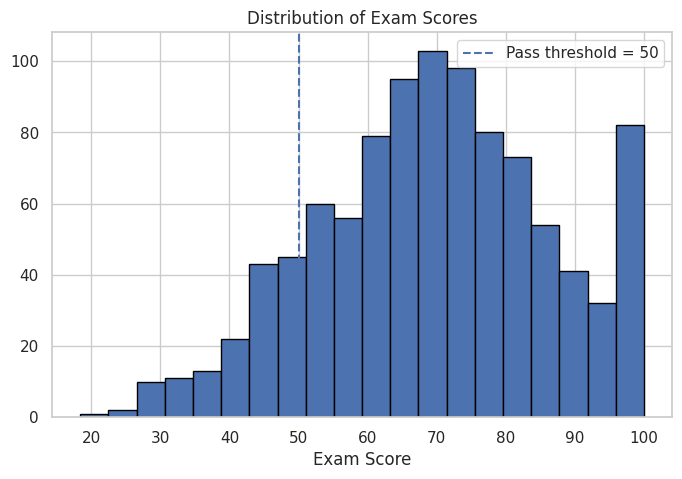

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing, "missing_percent": missing_pct})
display(missing_table[missing_table["missing_count"] > 0])

print("Unique values per column:")
display(df.nunique().sort_values().to_frame("unique_values"))

print("Exam score summary:")
display(df["exam_score"].describe())

plt.figure(figsize=(8, 5))
plt.hist(df["exam_score"], bins=20, edgecolor="black")
plt.axvline(50, linestyle="--", label="Pass threshold = 50")
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.legend()
plt.show()


## 4. Univariate EDA — Numerical Variables

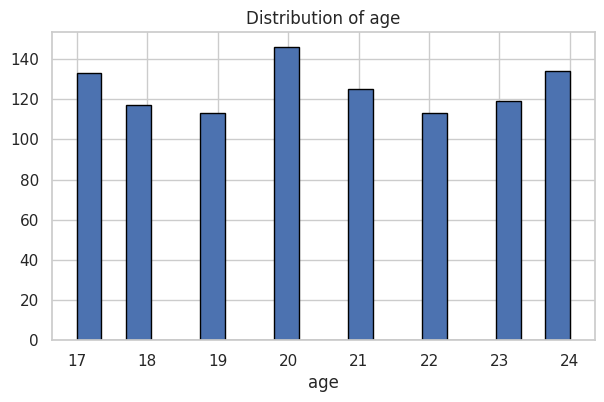

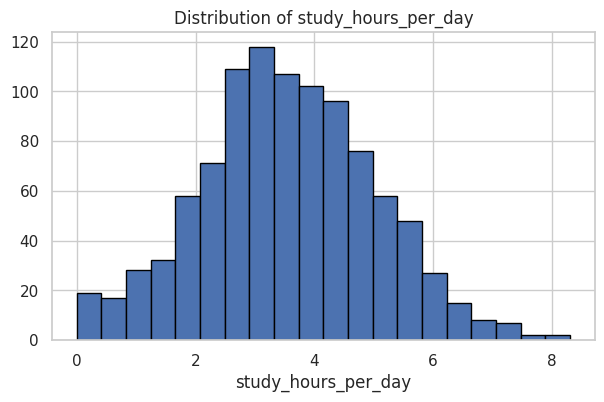

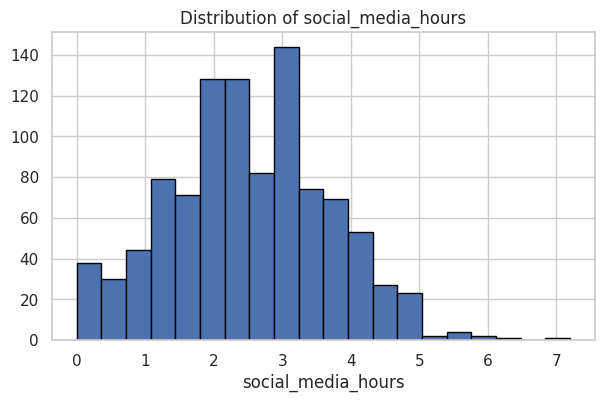

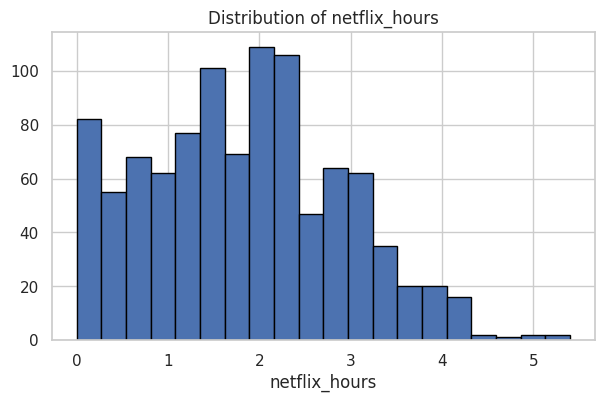

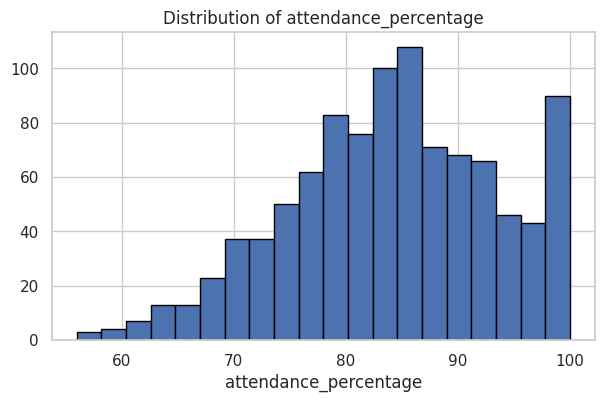

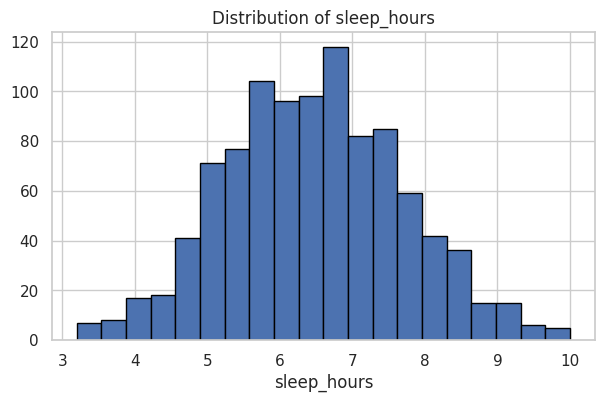

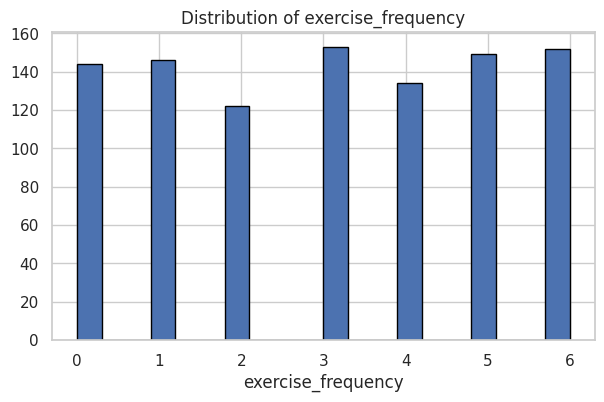

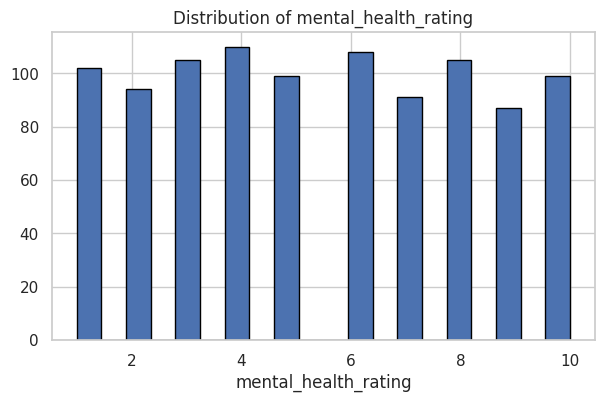

In [ ]:
num_for_plots = [c for c in numeric_cols if c != "exam_score"]

for col in num_for_plots:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col], bins=20, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.show()


## 5. Univariate EDA — Categorical Variables

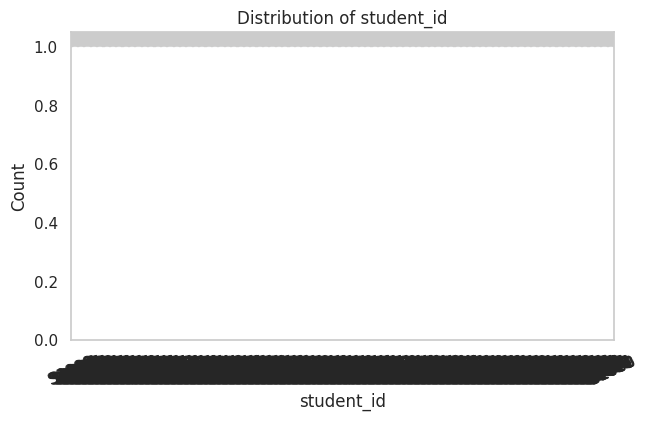

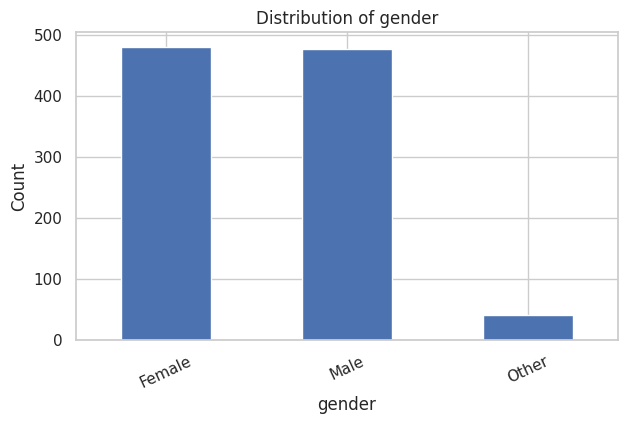

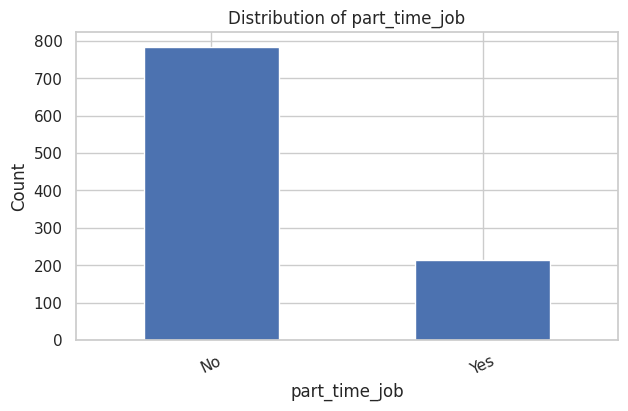

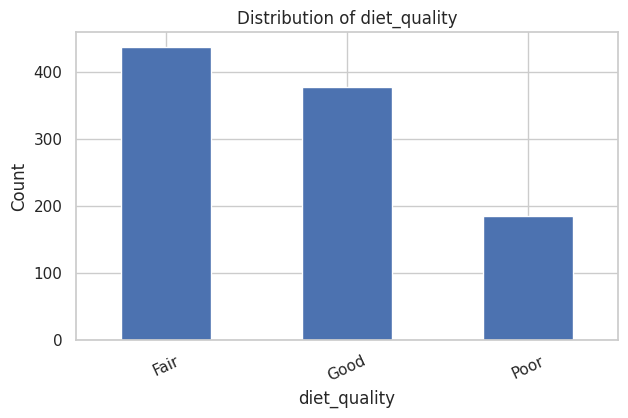

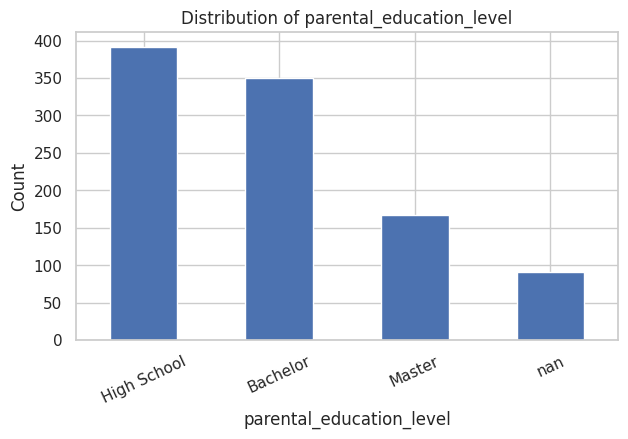

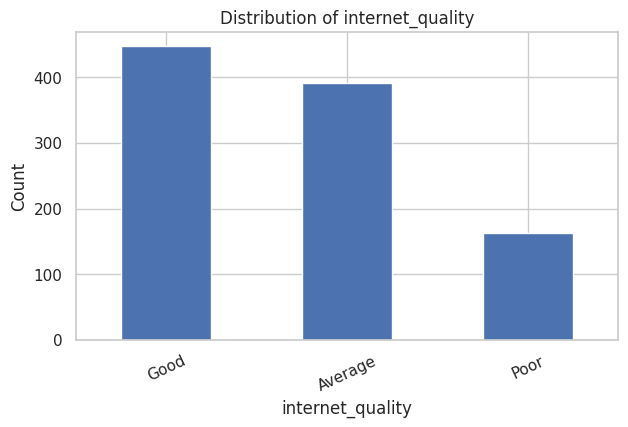

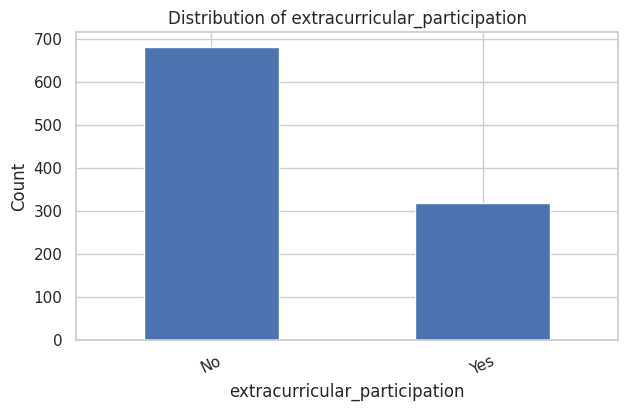

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(7, 4))
    order = df[col].value_counts(dropna=False).index
    df[col].value_counts(dropna=False).plot(kind="bar")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=25)
    plt.show()


## 6. Relationships with `exam_score`

For numerical variables, scatterplots and correlation values help identify direction and strength of linear relationships. For categorical variables, group wise mean exam scores provide a simple comparison.

Correlation should be interpreted as association, not causation.

Correlation with exam_score:


,correlation
exam_score,1.000000
study_hours_per_day,0.825419
mental_health_rating,0.321523
exercise_frequency,0.160107
sleep_hours,0.121683
attendance_percentage,0.089836
age,-0.008907
social_media_hours,-0.166733
netflix_hours,-0.171779


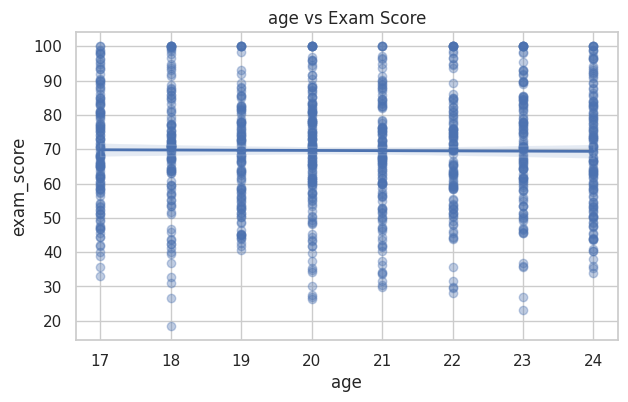

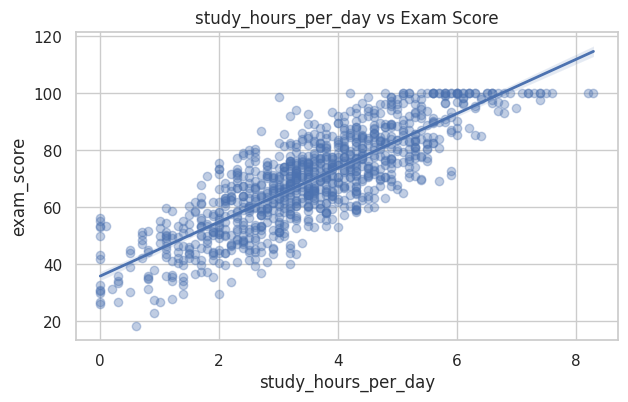

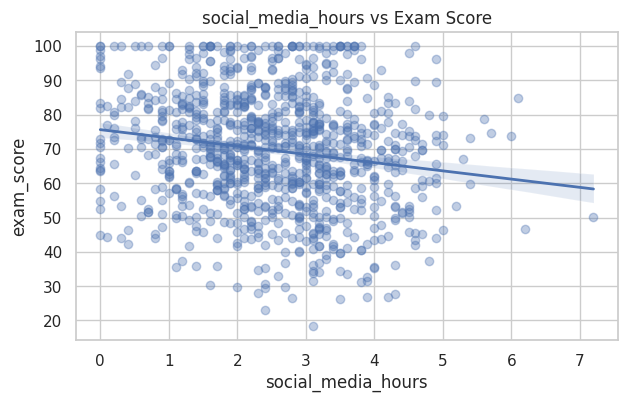

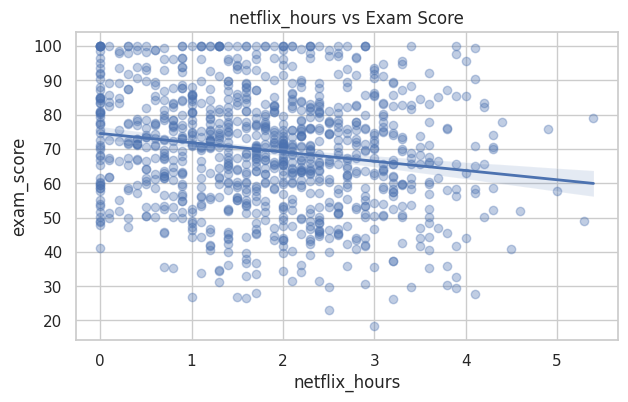

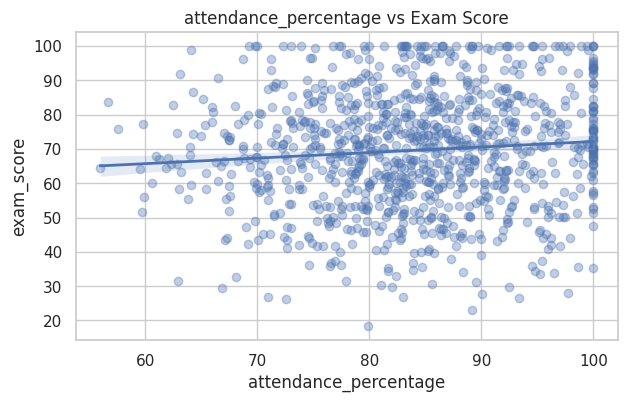

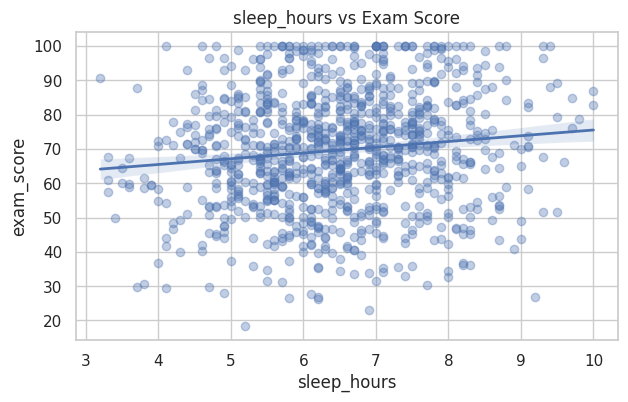

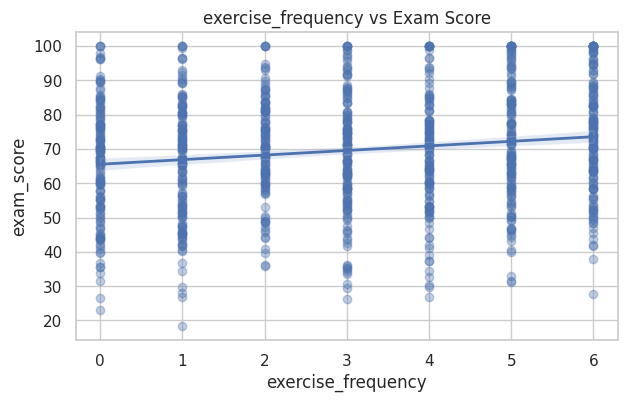

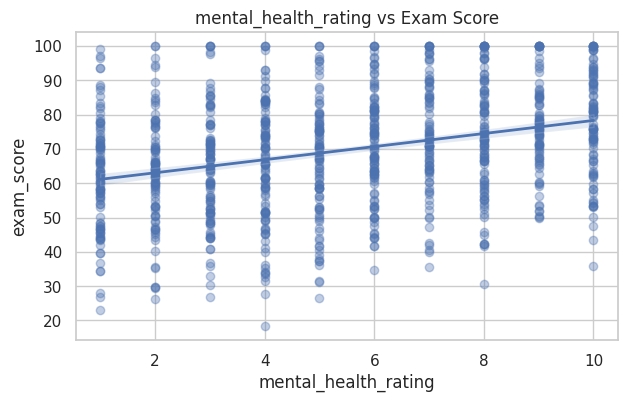


Mean exam score by student_id:


,mean_exam_score
student_id,
S1960,100.0
S1908,100.0
S1945,100.0
S1885,100.0
S1875,100.0
...,...
S1129,26.8
S1195,26.7
S1434,26.2


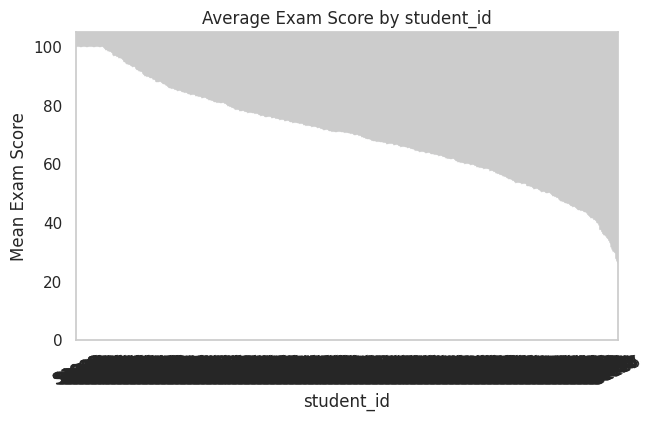


Mean exam score by gender:


,mean_exam_score
gender,
Other,70.647619
Female,69.741372
Male,69.368344


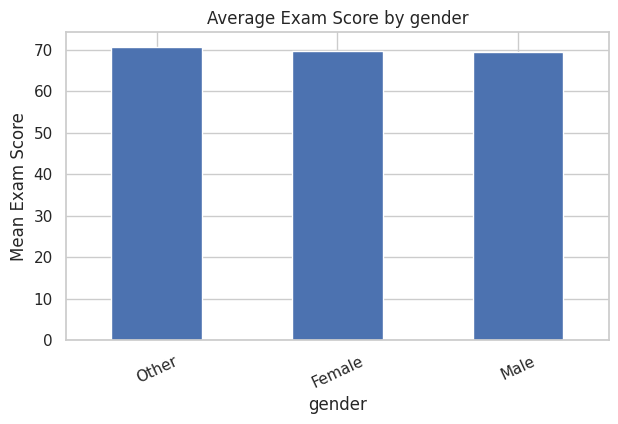


Mean exam score by part_time_job:


,mean_exam_score
part_time_job,
No,69.836561
Yes,68.743256


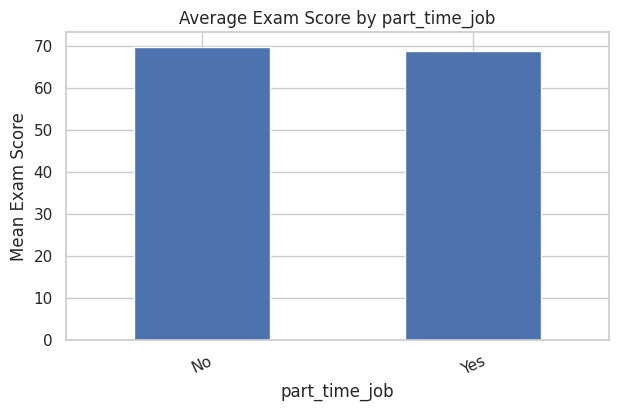


Mean exam score by diet_quality:


,mean_exam_score
diet_quality,
Fair,70.428833
Good,69.366402
Poor,68.127568


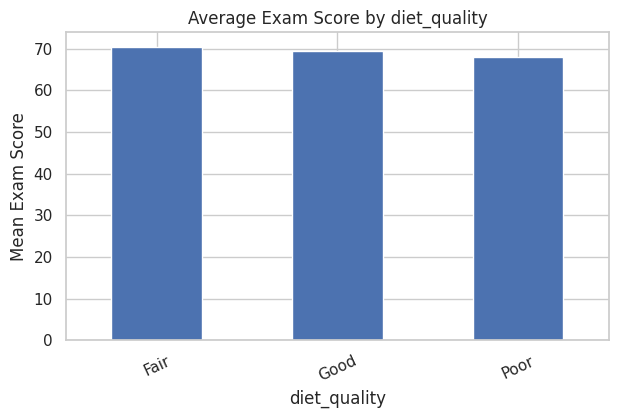


Mean exam score by parental_education_level:


,mean_exam_score
parental_education_level,
Bachelor,70.272571
NaN,70.034066
High School,69.547194
Master,68.086826


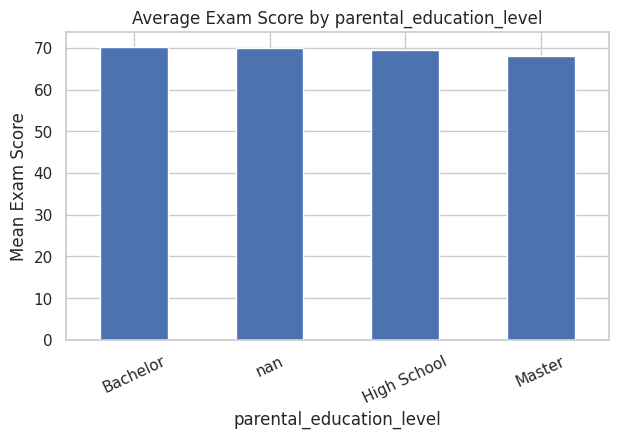


Mean exam score by internet_quality:


,mean_exam_score
internet_quality,
Average,70.643990
Poor,69.717284
Good,68.647651


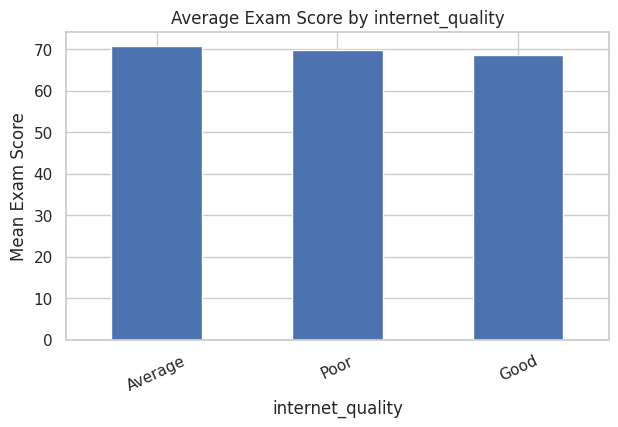


Mean exam score by extracurricular_participation:


,mean_exam_score
extracurricular_participation,
Yes,69.623270
No,69.591349


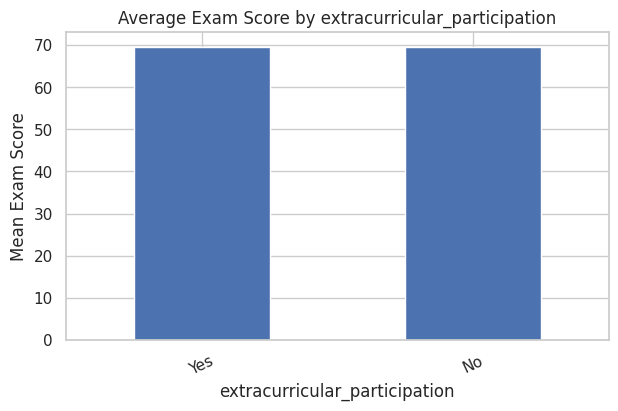

In [ ]:
corr_with_target = (
    df[numeric_cols]
    .corr(numeric_only=True)["exam_score"]
    .sort_values(ascending=False)
)

print("Correlation with exam_score:")
display(corr_with_target.to_frame("correlation"))

for col in num_for_plots:
    plt.figure(figsize=(7, 4))
    sns.regplot(data=df, x=col, y="exam_score",
                scatter_kws={"alpha": 0.35}, line_kws={"linewidth": 2})
    plt.title(f"{col} vs Exam Score")
    plt.show()

for col in categorical_cols:
    group_means = df.groupby(col, dropna=False)["exam_score"].mean().sort_values(ascending=False)
    print(f"\nMean exam score by {col}:")
    display(group_means.to_frame("mean_exam_score"))

    plt.figure(figsize=(7, 4))
    group_means.plot(kind="bar")
    plt.xlabel(col)
    plt.ylabel("Mean Exam Score")
    plt.title(f"Average Exam Score by {col}")
    plt.xticks(rotation=25)
    plt.show()


## 7. Correlation Heatmap

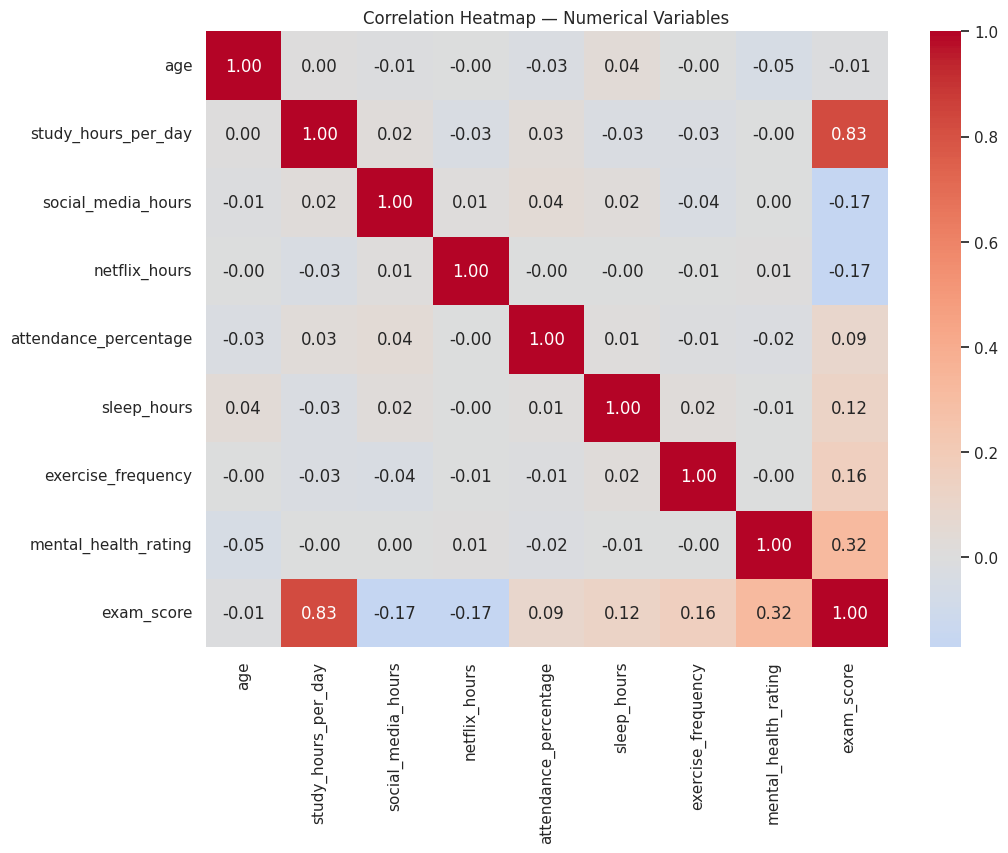

In [ ]:
plt.figure(figsize=(11, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Numerical Variables")
plt.show()


## 8. Potential Outliers

The IQR rule is used as a screening method. A value flagged by IQR is not automatically an error; realistic extreme observations may contain useful information. Therefore, this analysis reports potential outliers rather than deleting them blindly.

,variable,Q1,Q3,lower_bound,upper_bound,potential_outliers
0,age,18.750,23.000,12.3750,29.3750,0
1,study_hours_per_day,2.600,4.500,-0.2500,7.3500,7
2,social_media_hours,1.700,3.300,-0.7000,5.7000,5
3,netflix_hours,1.000,2.525,-1.2875,4.8125,4
4,attendance_percentage,78.000,91.025,58.4625,110.5625,3
5,sleep_hours,5.600,7.300,3.0500,9.8500,2
6,exercise_frequency,1.000,5.000,-5.0000,11.0000,0
7,mental_health_rating,3.000,8.000,-4.5000,15.5000,0
8,exam_score,58.475,81.325,24.2000,115.6000,2


/tmp/ipykernel_8624/2956467061.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[c].dropna() for c in numeric_cols], labels=numeric_cols)


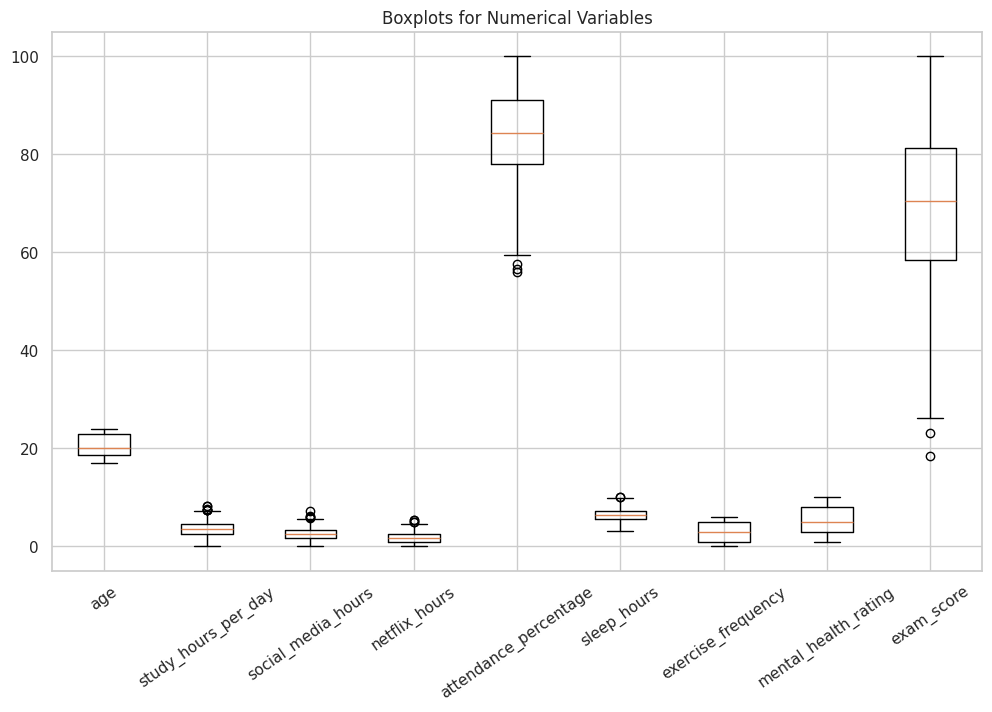

In [ ]:
outlier_summary = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append([col, q1, q3, lower, upper, int(count)])

outlier_table = pd.DataFrame(
    outlier_summary,
    columns=["variable", "Q1", "Q3", "lower_bound", "upper_bound", "potential_outliers"]
)
display(outlier_table)

plt.figure(figsize=(12, 7))
plt.boxplot([df[c].dropna() for c in numeric_cols], labels=numeric_cols)
plt.title("Boxplots for Numerical Variables")
plt.xticks(rotation=35)
plt.show()


## 9. EDA Findings

Based on the observed dataset:

- `study_hours_per_day` has the strongest positive linear association with `exam_score`.
- `mental_health_rating` shows a moderate positive association.
- `exercise_frequency` and `sleep_hours` show weaker positive relationships.
- `social_media_hours` and `netflix_hours` show negative associations with exam score.
- `attendance_percentage` is positively associated with score, but the relationship is relatively weak in this dataset.
- `parental_education_level` contains missing values, so it needs preprocessing before machine learning.
- Several numeric variables have IQR-flagged observations, but their values are within plausible ranges, so they are retained rather than removed.
- The Pass/Fail classes are imbalanced toward Pass, so accuracy should be considered alongside precision, recall, and F1-score.


## 10. Prepare Data for Machine Learning

`student_id` is an identifier and is excluded because it should not provide predictive information.

All remaining variables are retained as potentially useful predictors. Numerical variables are median imputed and standardized. Categorical variables are filled with the most frequent category and one hot encoded.

Using a preprocessing pipeline keeps the transformations learned from the training set only, avoiding data leakage.

In [ ]:
X = df.drop(columns=["exam_score", "student_id"])
y_reg = df["exam_score"]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.20, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Features used:", X.columns.tolist())


Training rows: 800
Testing rows: 200
Features used: ['age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation']


## 11. Regression — Linear Regression

The objective is to predict the continuous `exam_score`.

Evaluation metrics:
- **MAE:** average absolute prediction error; lower is better.
- **MSE:** average squared prediction error; lower is better.
- **RMSE:** square root of MSE, expressed in the target's units; lower is better.
- **R²:** proportion of target variance explained by the model; higher is better.


In [ ]:
linear_regression = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_regression.fit(X_train, y_train)

y_train_pred = linear_regression.predict(X_train)
y_test_pred = linear_regression.predict(X_test)

regression_results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Training": [
        mean_absolute_error(y_train, y_train_pred),
        mean_squared_error(y_train, y_train_pred),
        np.sqrt(mean_squared_error(y_train, y_train_pred)),
        r2_score(y_train, y_train_pred)
    ],
    "Testing": [
        mean_absolute_error(y_test, y_test_pred),
        mean_squared_error(y_test, y_test_pred),
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        r2_score(y_test, y_test_pred)
    ]
})

display(regression_results.round(4))


,Metric,Training,Testing
0,MAE,4.2142,4.1923
1,MSE,28.5661,26.5325
2,RMSE,5.3447,5.1510
3,R²,0.9021,0.8965


### Regression: Actual vs Predicted

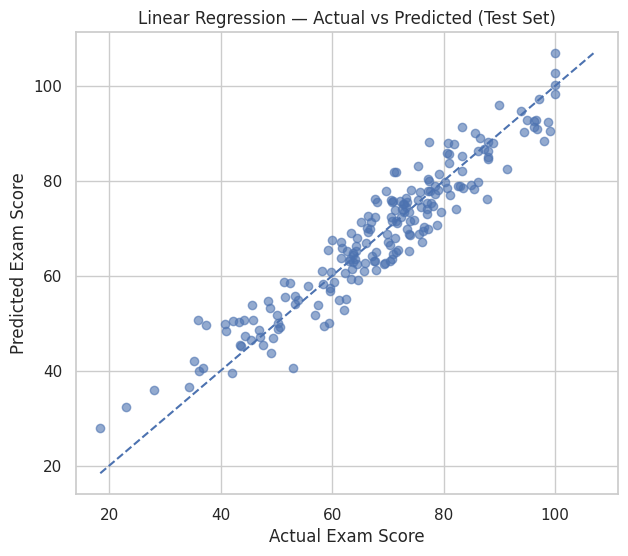

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
min_score = min(y_test.min(), y_test_pred.min())
max_score = max(y_test.max(), y_test_pred.max())
plt.plot([min_score, max_score], [min_score, max_score], linestyle="--")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Linear Regression — Actual vs Predicted (Test Set)")
plt.show()


### Regression: Residual Diagnostics

Residuals are the differences between actual and predicted values. A reasonable model should not show a strong systematic pattern in residuals.

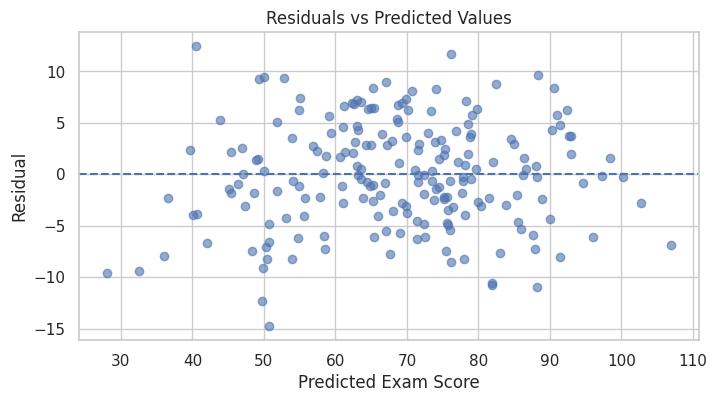

Mean test residual: -0.042841180074019825


In [ ]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 4))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Exam Score")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")
plt.show()

print("Mean test residual:", residuals.mean())


## 12. Regression Feature Importance

For Linear Regression, coefficients show the direction and relative contribution after preprocessing. Because numerical features are standardized, their coefficients are more directly comparable with one another. One-hot encoded category coefficients represent differences relative to the corresponding reference category.

In [ ]:
feature_names = linear_regression.named_steps["preprocessor"].get_feature_names_out()
coefficients = linear_regression.named_steps["model"].coef_

coef_table = (
    pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
    .assign(abs_coefficient=lambda d: d["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
)

display(coef_table.head(15).round(4))


,feature,coefficient,abs_coefficient
1,num__study_hours_per_day,14.1448,14.1448
7,num__mental_health_rating,5.5651,5.5651
2,num__social_media_hours,-3.1297,3.1297
6,num__exercise_frequency,2.6567,2.6567
3,num__netflix_hours,-2.5316,2.5316
5,num__sleep_hours,2.4219,2.4219
4,num__attendance_percentage,1.3496,1.3496
13,cat__diet_quality_Fair,0.5026,0.5026
10,cat__gender_Other,0.4916,0.4916
14,cat__diet_quality_Good,-0.4553,0.4553


## 13. Create the Classification Target

A second problem is created from the same original dataset:

- `Pass` = `exam_score >= 50`
- `Fail` = `exam_score < 50`

The original `exam_score` is **not** included as a predictor because doing so would leak the answer into the model.

Class distribution:


,count
exam_score,
Pass,869
Fail,131


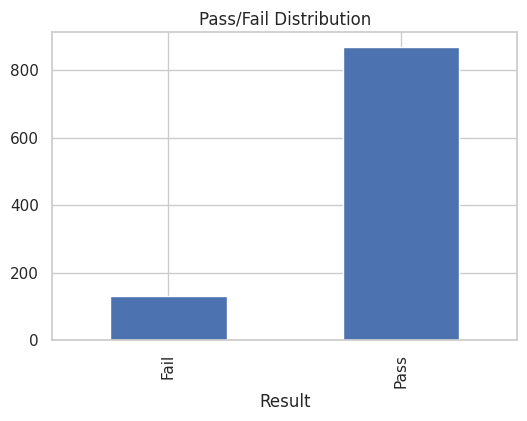

In [ ]:
y_cls = (df["exam_score"] >= 50).astype(int)

print("Class distribution:")
class_counts = y_cls.map({0: "Fail", 1: "Pass"}).value_counts()
display(class_counts.to_frame("count"))

plt.figure(figsize=(6, 4))
y_cls.map({0: "Fail", 1: "Pass"}).value_counts().reindex(["Fail", "Pass"]).plot(kind="bar")
plt.title("Pass/Fail Distribution")
plt.xlabel("Result")
plt.show()

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_cls, test_size=0.20, random_state=42, stratify=y_cls
)


## 14. Classification — Logistic Regression

Logistic Regression is suitable for a binary Pass/Fail outcome. The model uses exactly the same prepared feature set and preprocessing strategy as the regression task.

In [ ]:
logistic_regression = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

logistic_regression.fit(X_train_c, y_train_c)

y_train_cls_pred = logistic_regression.predict(X_train_c)
y_test_cls_pred = logistic_regression.predict(X_test_c)

classification_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Training": [
        accuracy_score(y_train_c, y_train_cls_pred),
        precision_score(y_train_c, y_train_cls_pred),
        recall_score(y_train_c, y_train_cls_pred),
        f1_score(y_train_c, y_train_cls_pred)
    ],
    "Testing": [
        accuracy_score(y_test_c, y_test_cls_pred),
        precision_score(y_test_c, y_test_cls_pred),
        recall_score(y_test_c, y_test_cls_pred),
        f1_score(y_test_c, y_test_cls_pred)
    ]
})

display(classification_results.round(4))

print("Classification report — Test Set")
print(classification_report(
    y_test_c, y_test_cls_pred, target_names=["Fail", "Pass"]
))


,Metric,Training,Testing
0,Accuracy,0.9575,0.9550
1,Precision,0.9701,0.9714
2,Recall,0.9813,0.9770
3,F1-score,0.9757,0.9742


Classification report — Test Set
              precision    recall  f1-score   support

        Fail       0.84      0.81      0.82        26
        Pass       0.97      0.98      0.97       174

    accuracy                           0.95       200
   macro avg       0.91      0.89      0.90       200
weighted avg       0.95      0.95      0.95       200



### Confusion Matrix

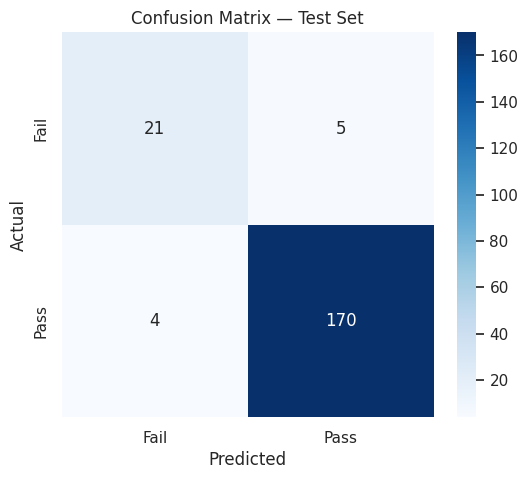

Confusion matrix:
[[ 21   5]
 [  4 170]]


In [ ]:
cm = confusion_matrix(y_test_c, y_test_cls_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Test Set")
plt.show()

print("Confusion matrix:")
print(cm)


## 15. Training vs Testing Performance — Overfitting / Underfitting

A large gap between training and testing performance can indicate overfitting. If both training and testing performance are poor, the model may be underfitting.

For this dataset, the comparison is made directly using the metric tables above.

In [ ]:
# Compact comparison and simple interpretation
reg_r2_train = r2_score(y_train, y_train_pred)
reg_r2_test = r2_score(y_test, y_test_pred)
reg_gap = reg_r2_train - reg_r2_test

cls_acc_train = accuracy_score(y_train_c, y_train_cls_pred)
cls_acc_test = accuracy_score(y_test_c, y_test_cls_pred)
cls_gap = cls_acc_train - cls_acc_test

print(f"Regression R² gap (train - test): {reg_gap:.4f}")
print(f"Classification accuracy gap (train - test): {cls_gap:.4f}")

if abs(reg_gap) < 0.05:
    print("Regression: training and testing R² are close, so there is no strong evidence of overfitting.")
else:
    print("Regression: the train-test R² gap deserves further investigation for possible overfitting.")

if abs(cls_gap) < 0.05:
    print("Classification: training and testing accuracy are close, so there is no strong evidence of overfitting.")
else:
    print("Classification: the train-test accuracy gap deserves further investigation for possible overfitting.")


Regression R² gap (train - test): 0.0056
Classification accuracy gap (train - test): 0.0025
Regression: training and testing R² are close, so there is no strong evidence of overfitting.
Classification: training and testing accuracy are close, so there is no strong evidence of overfitting.


## 16. Final Findings and 5 Meaningful Insights

### Model findings

The Linear Regression model should be judged primarily by its test set MAE, RMSE, and R². The Logistic Regression model should be judged using the test confusion matrix together with accuracy, precision, recall, and F1-score.

The train/test comparisons indicate whether the models generalize reasonably well rather than simply memorizing the training data.

### Five evidence-based student-performance insights

1. **Study time is the strongest observed predictor of exam score.**  
   `study_hours_per_day` has by far the strongest positive correlation with `exam_score`, making study time the clearest behavioral signal in this dataset.

2. **Mental health is positively associated with academic performance.**  
   `mental_health_rating` has a meaningful positive relationship with exam score, suggesting that better self reported mental well being tends to coincide with higher scores in this sample.

3. **Entertainment/social-media time is associated with lower scores.**  
   Both `social_media_hours` and `netflix_hours` have negative correlations with exam score. These are associations, so the analysis does not establish that reducing these activities alone causes higher marks.

4. **Sleep and exercise show positive but weaker relationships.**  
   `sleep_hours` and `exercise_frequency` are positively associated with exam score, but their relationships are considerably weaker than study hours.

5. **The model can distinguish likely passes from fails with high test performance, but the threshold creates an imbalanced classification problem.**  
   Most students in the dataset score at least 50, so accuracy alone can be misleading. Precision, recall, F1-score, and the confusion matrix provide a more complete picture of Pass/Fail performance.

> **Important:** These conclusions describe patterns in this dataset. They should not be interpreted as causal claims or as universal rules for all students.


## 17. Conclusion

This project demonstrates an end-to-end supervised machine learning workflow:

- EDA was used to understand variable types, distributions, missing values, correlations, relationships, and potential outliers.
- Data preprocessing was handled with a reproducible `scikit-learn` pipeline.
- Linear Regression was used to predict the continuous `exam_score`.
- Logistic Regression was used to classify students as Pass or Fail using a 50 mark threshold.
- Regression and classification were evaluated on both training and testing data.
- The final comparison helps assess generalization and identify potential overfitting or underfitting.

Overall, the analysis shows that **study habits are particularly informative for exam performance**, while lifestyle and well-being variables provide additional predictive signal.
